# Samplomatic & Executor: IBM's Phase 3 Primitives

**The evolution from Sampler/Estimator to modular, client-side error mitigation**

---

## The Evolution of IBM Quantum Primitives

IBM's quantum execution stack has evolved through three distinct phases:

| Phase | Name | What it offers |
|-------|------|----------------|
| **Phase 1** | One Knob | Users select a resilience level (0–3). The runtime makes all error-mitigation choices server-side. Simple but opaque. |
| **Phase 2** | Guided Control | Resilience levels still supported, but users can also define custom options (e.g., ZNE with specific noise factors and extrapolators). More flexibility, still server-driven. |
| **Phase 3** | Modular Error Mitigation | Near-complete control on the **client side**. Users compose error-mitigation protocols from modular building blocks and run them locally. |

### Why Phase 3?

Phase 1 and 2 used **Sampler** and **Estimator** as high-level abstractions that bundled transpilation, error mitigation, and execution into a single server-side call. This was convenient but:

- **Opaque**: hard to know exactly what mitigation was applied
- **Inflexible**: limited to pre-defined strategies
- **Slow to iterate**: every change required a full server round-trip

Phase 3 **unbundles** these concerns into three modular tools:

| Tool | Role |
|------|------|
| **Samplomatic** | Client-side circuit randomization library (Pauli twirling, etc.). Vendor-agnostic. Describes randomization as a graph called a "samplex". |
| **Executor** | New low-level primitive. Sampler-like, but accepts samplex graphs for server-side randomization at scale. |
| **Noise Learner** | Accepts circuit layers, returns noise models. Refreshed version of the existing service. |

This notebook covers:
- **Part 1: Samplomatic** — boxes, twirling, introspection, and hardware execution via SamplerV2
- **Part 2: Executor** — server-side randomization at scale
- **InjectNoise** — annotation for Probabilistic Error Cancellation (PEC)
- **ChangeBasis** — annotation for measuring in X/Y bases
- **Full PEC Pipeline** — NoiseLearnerV3 + Executor end-to-end

---

## Part 1: Samplomatic

### What is Samplomatic?

Samplomatic is a **Python library for circuit randomization** — the process of inserting random Pauli gates (twirling) around noisy operations to reshape noise into a simpler, more predictable form.

Key properties:
- **Vendor-agnostic**: works with any Qiskit circuit, not tied to IBM backends
- **Client-side**: all randomization logic runs locally — no server calls needed
- **Graph-based**: describes randomization as a directed acyclic graph called a **"samplex"**
- **Parametric**: builds a single parameterized template circuit, then samples different randomization parameters — potentially **millions of randomizations per hour**

### Why Twirling Matters

Pauli twirling converts arbitrary noise channels into **stochastic Pauli channels** — diagonal in the Pauli basis. This makes noise:
- Easier to characterize (via noise learning)
- Easier to mitigate (via techniques like PEC, ZNE)
- More predictable across circuit instances

### Samplomatic vs. the Runtime Stack

The IBM Quantum Runtime already does twirling server-side. So why use samplomatic?

- **Compile and execute locally** — faster iteration
- **Parametric circuits** — build once, sample many
- **Full introspection** — inspect exactly what each randomization does to your circuit's unitary
- **Composable** — combine with custom error mitigation protocols

---

## Setup

In [14]:
# pip install samplomatic  # uncomment if not installed
# pip install -U git+https://github.com/Qiskit/qiskit-ibm-runtime.git@executor_preview

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Operator
from samplomatic import Twirl, build
from samplomatic.transpiler import generate_boxing_pass_manager

---

## Hello World: Boxing and Twirling

Samplomatic works by **boxing** regions of your circuit — marking which gates should be twirled together — and then **building** a parametric template + samplex graph from the boxed circuit.

### Step 1: Create a boxed circuit

Use `QuantumCircuit.box()` context manager with `Twirl()` annotations to mark regions for Pauli twirling.

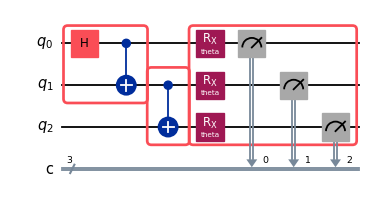

In [79]:
boxed_circuit = QuantumCircuit(3, 3)

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.h(0)
    boxed_circuit.cx(0, 1)

with boxed_circuit.box(annotations=[Twirl(decomposition="rzrx")]):
    boxed_circuit.cx(1, 2)

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.rx(Parameter("theta"), [0, 1, 2])
    boxed_circuit.measure([0, 1, 2], [0, 1, 2])

boxed_circuit.draw("mpl", scale=0.65)

### Step 2: Build the template circuit and samplex

`build()` takes a boxed circuit and returns two things:
1. **template_circuit** — a single parametric circuit with twirling parameters inserted (the circuit you send to the backend)
2. **samplex** — a graph describing how to sample random values for those parameters

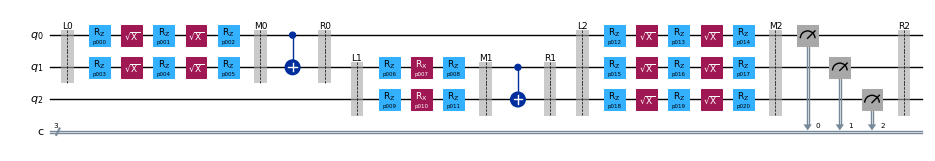

In [80]:
template_circuit, samplex = build(boxed_circuit)
template_circuit.draw("mpl", scale=0.5, fold=-1)

### Step 3: Sample randomized parameter sets

The samplex knows how to generate random twirling parameters. You provide any user-defined parameter values (like `theta`) and request N randomizations.

In [81]:
samplex_input = {"parameter_values": [0.1]}

outputs = samplex.sample(samplex_input, num_randomizations=5)

parameter_values = outputs["parameter_values"]
measurement_flips = outputs["measurement_flips.c"]

print(f"Parameter values shape: {parameter_values.shape}")
print(f"Measurement flips shape: {measurement_flips.shape}")
print(f"Each row is one randomization with all circuit parameters filled in")

Parameter values shape: (5, 21)
Measurement flips shape: (5, 1, 3)
Each row is one randomization with all circuit parameters filled in


---

## Introspecting Randomizations

A key advantage of client-side randomization: you can **inspect exactly what each randomization does** to your circuit's unitary matrix. Each randomization produces a different unitary that is equivalent to the original up to Pauli corrections on the measurements.

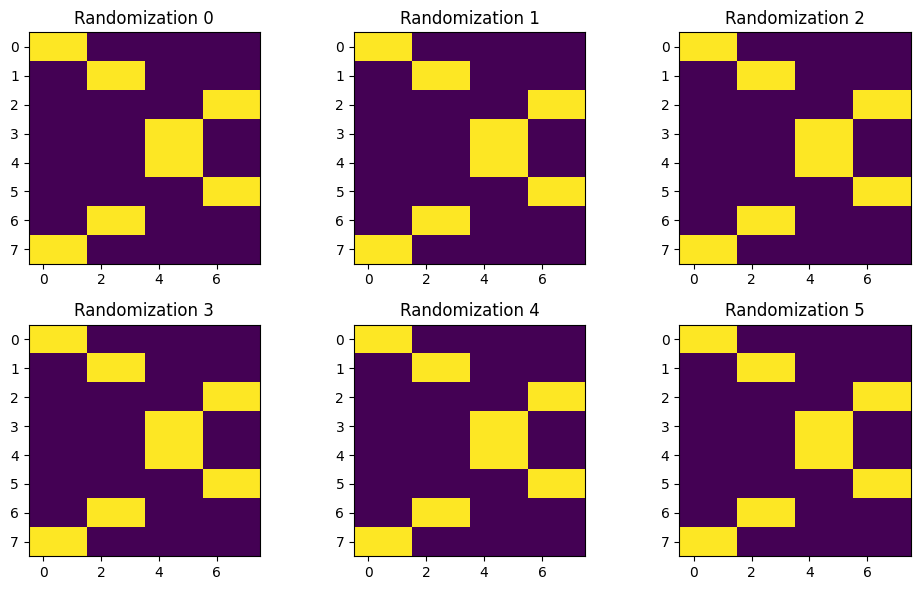

In [91]:
from qiskit.quantum_info import Pauli

num_randomizations = 6
outputs = samplex.sample(samplex_input, num_randomizations=num_randomizations)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for idx in range(num_randomizations):
    bound_template = template_circuit.assign_parameters(
        outputs["parameter_values"][idx]
    )
    bound_template.remove_final_measurements()
    bound_unitary_org = Operator(bound_template)

    if "measurement_flips.c" in outputs:
        meas_flips = Pauli(([0] * 3, outputs["measurement_flips.c"][idx, 0]))
        bound_unitary_new = bound_unitary_org & meas_flips

    ax = axes[idx // 3, idx % 3]
    ax.imshow(np.abs(bound_unitary_new))
    ax.set_title(f"Randomization {idx}")

plt.tight_layout()
plt.show()

---

## Boxing Pass Manager

Manually wrapping every gate in `box()` calls is tedious. Samplomatic provides a **transpiler pass manager** that automatically boxes gates and/or measurements in your circuit.

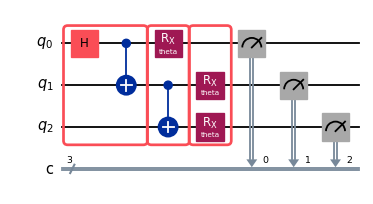

In [92]:
boxing_pass_manager = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=False,
)

circuit = QuantumCircuit(3, 3)
circuit.h(0)
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.rx(Parameter("theta"), [0, 1, 2])
circuit.measure([0, 1, 2], [0, 1, 2])

boxed_circuit = boxing_pass_manager.run(circuit)
boxed_circuit.draw("mpl", scale=0.65)

---

## Running on Real Hardware: ibm_marrakesh

Now the real test — send samplomatic-twirled circuits to an actual quantum processor. The workflow:

1. Build a circuit with samplomatic boxing
2. Transpile the **template circuit** for the target backend
3. Sample randomized parameter sets from the samplex
4. Bind parameters and submit each randomization via **SamplerV2**
5. Post-process results using `measurement_flips.c` to undo Pauli corrections on measurements

We'll compare **twirled** (samplomatic) vs **untwirled** (baseline) results to see the effect of Pauli twirling on real hardware noise.

In [16]:
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.backend("ibm_marrakesh")
print(f"Backend: {backend.name}")
print(f"Qubits: {backend.num_qubits}")
print(f"Pending jobs: {backend.status().pending_jobs}")

Backend: ibm_marrakesh
Qubits: 156
Pending jobs: 0


### Build a GHZ circuit with samplomatic twirling

We'll use a 3-qubit GHZ state — simple enough to verify, complex enough to show twirling effects.

Template circuit parameters: 27 (twirling params added)


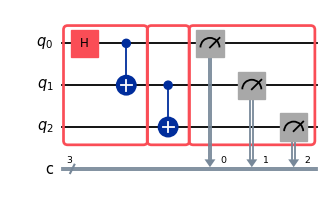

In [17]:
NUM_QUBITS = 3
SHOTS = 4096
NUM_RANDOMIZATIONS = 32

ghz = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)
ghz.h(0)
for i in range(NUM_QUBITS - 1):
    ghz.cx(i, i + 1)
ghz.measure(range(NUM_QUBITS), range(NUM_QUBITS))

boxing_pm = generate_boxing_pass_manager(enable_gates=True, enable_measures=True)
boxed_ghz = boxing_pm.run(ghz)

template_ghz, samplex_ghz = build(boxed_ghz)

print(f"Template circuit parameters: {len(template_ghz.parameters)} (twirling params added)")
boxed_ghz.draw("mpl", scale=0.65, fold=-1)

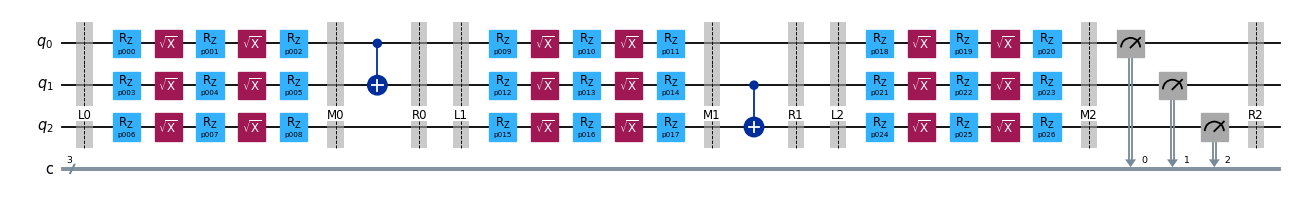

In [18]:
template_ghz.draw("mpl", scale=0.65, fold=-1)

### Transpile for ibm_marrakesh and sample randomizations

Parameter values shape: (32, 27)
Measurement flips shape: (32, 1, 3)


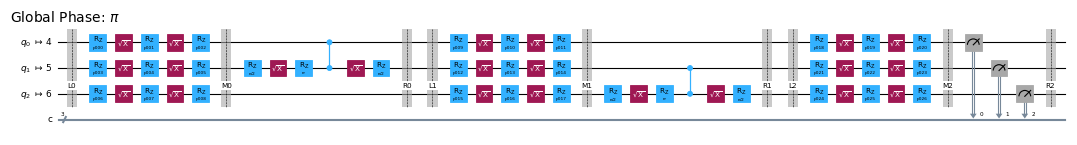

In [19]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

isa_template = pm.run(template_ghz)
isa_baseline = pm.run(ghz)

samplex_input = {}
outputs = samplex_ghz.sample(samplex_input, num_randomizations=NUM_RANDOMIZATIONS)

print(f"Parameter values shape: {outputs['parameter_values'].shape}")
print(f"Measurement flips shape: {outputs['measurement_flips.c'].shape}")
isa_template.draw("mpl", scale=0.4, fold=-1)

### Submit to ibm_marrakesh: twirled + baseline

We submit all randomized circuits plus the untwirled baseline in a single **Batch** for efficiency.

In [20]:
twirled_jobs = []
baseline_job = None

with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)

    for idx in range(NUM_RANDOMIZATIONS):
        bound_circuit = isa_template.assign_parameters(
            outputs["parameter_values"][idx]
        )
        twirled_jobs.append(sampler.run([bound_circuit], shots=SHOTS))

    baseline_job = sampler.run([isa_baseline], shots=SHOTS)

print(f"Submitted {NUM_RANDOMIZATIONS} twirled + 1 baseline job(s)")

Submitted 32 twirled + 1 baseline job(s)


### Collect results and apply measurement corrections

Samplomatic's `measurement_flips.c` tells us which measurement outcomes need to be bit-flipped for each randomization (named after the classical register `c`). This is the Pauli correction on the classical output — without it, twirled results would look scrambled.

In [23]:
from collections import Counter


def apply_meas_flips(counts: dict, flips: np.ndarray) -> dict:
    """Flip bits in measurement outcomes according to measurement_flips."""
    corrected = Counter()
    flip_int = int(np.packbits(flips.astype(np.uint8), bitorder="little")[0]) & ((1 << len(flips)) - 1)
    for bitstring, count in counts.items():
        val = int(bitstring, 2) ^ flip_int
        corrected[format(val, f"0{len(bitstring)}b")] += count
    return dict(corrected)


baseline_result = baseline_job.result()
baseline_counts = baseline_result[0].data.c.get_counts()
print(f"Baseline (no twirling): {baseline_counts}")

twirled_counts_all = []
for idx, job in enumerate(twirled_jobs):
    result = job.result()
    raw_counts = result[0].data.c.get_counts()

    corrected = apply_meas_flips(raw_counts, outputs["measurement_flips.c"][idx, 0])
    twirled_counts_all.append(corrected)

averaged_counts = Counter()
for counts in twirled_counts_all:
    averaged_counts.update(counts)
total_shots = sum(averaged_counts.values())
averaged_probs = {k: v / total_shots for k, v in averaged_counts.items()}

print(f"\nTwirled (averaged over {NUM_RANDOMIZATIONS} randomizations):")
for k in sorted(averaged_probs, key=averaged_probs.get, reverse=True)[:5]:
    print(f"  |{k}⟩: {averaged_probs[k]:.4f}")

Baseline (no twirling): {'110': 53, '000': 2015, '111': 1986, '011': 15, '101': 10, '100': 11, '001': 5, '010': 1}

Twirled (averaged over 32 randomizations):
  |111⟩: 0.4832
  |000⟩: 0.4812
  |110⟩: 0.0129
  |001⟩: 0.0122
  |100⟩: 0.0032


---

## Part 2: Executor — Server-Side Randomization at Scale

### The Scaling Problem with SamplerV2

In Part 1, we built a parametric template and samplex with samplomatic, then **sampled parameters locally** and submitted each randomization as a separate bound circuit via SamplerV2.

This works for 10 randomizations, but production error mitigation (PEC, ZNE) needs **thousands to millions**. Client-side binding and per-circuit submission hits memory and queue limits long before that.

### What Executor Does

**Executor** is a new Qiskit Runtime primitive that accepts the `(template, samplex)` pair directly via a `QuantumProgram`. The server generates all randomized parameter bindings and executes them in an optimized shot loop — you never materialize millions of circuits on your machine.

| Randomizations | SamplerV2 (Part 1) | Executor (Part 2) |
|---------------|--------------------|--------------------|
| 10 | 10 jobs, 10 circuits bound locally | 1 job, shape=(10,) |
| 1,000 | 1,000 jobs, 1,000 circuits in memory | 1 job, shape=(1000,) |
| 1,000,000 | Not feasible | 1 job, shape=(1000000,) |

In [24]:
from qiskit_ibm_runtime.quantum_program import QuantumProgram
from qiskit_ibm_runtime.executor import Executor
from qiskit_ibm_runtime.noise_learner_v3 import NoiseLearnerV3

### QuantumProgram: The Container

A `QuantumProgram` holds one or more **items** — each is a circuit plus instructions on how to parameterize and execute it.

| Item type | Method | Use case |
|-----------|--------|----------|
| **Samplex circuit** | `append_samplex_item(template, samplex, samplex_arguments, shape)` | Server-side randomization from samplex graph |
| **Parameterized circuit** | `append_circuit_item(circuit, circuit_arguments=array)` | Parameter sweeps without samplex |
| **Static circuit** | `append_circuit_item(circuit)` | Fixed circuit, no parameters |

The `shape` tuple tells the server how many randomizations to produce — e.g., `shape=(900,)` means 900 independent randomized parameter sets, each executed for `shots` repetitions.

We reuse `isa_template` and `samplex_ghz` from Part 1 to show the same GHZ circuit submitted via Executor instead of SamplerV2.

In [25]:
program = QuantumProgram(shots=SHOTS)

program.append_samplex_item(
    isa_template,
    samplex=samplex_ghz,
    samplex_arguments={},
    shape=(NUM_RANDOMIZATIONS,),
)

print(program)
print(f"  Shape: ({NUM_RANDOMIZATIONS},), {SHOTS} shots each")

QuantumProgram(shots=4096, items=[
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x23d6f852550>, <Samplex @ 0x23d6b6fdc90>, shape=(32,)),
])
  Shape: (32,), 4096 shots each


### Running with Executor

`Executor` takes a backend (same as SamplerV2). The key difference: one `program.run()` call replaces the entire SamplerV2 loop from Part 1.

**Result structure** — Executor returns numpy boolean arrays, not count dictionaries:
- `result[i]["meas"]` — raw measurement bits, shape `(num_shots, *shape, num_bits)`
- `result[i]["measurement_flips.meas"]` — Pauli correction bits, shape `(*shape, num_bits)`

Undo twirling with a simple XOR: `corrected = result["meas"] ^ result["measurement_flips.meas"]`

In [26]:
executor = Executor(backend)
executor_job = executor.run(program)
print(f"Job ID: {executor_job.job_id()}")

executor_results = executor_job.result()
print(f"Result items: {len(executor_results)}")
print(f"Keys: {list(executor_results[0].keys())}")

Job ID: d6g44jekeflc73agveog
Result items: 1
Keys: ['c', 'measurement_flips.c']


### Post-Processing Executor Results

Compare result processing with Part 1:

| Aspect | Part 1 (SamplerV2) | Part 2 (Executor) |
|--------|--------------------|--------------------|
| **Collection** | Loop over N job objects | Single `result` object |
| **Indexing** | `job.result()[0].data.c.get_counts()` | `result[item_idx]["register_name"]` |
| **Format** | Count dictionaries | Raw boolean numpy arrays |
| **Flips** | Manual per-randomization string XOR | Broadcastable numpy XOR over entire array |

In [32]:
twirl_result = executor_results[0]
print(f"Raw meas shape: {twirl_result['c'].shape}")
print(f"Flips shape: {twirl_result['measurement_flips.c'].shape}")

corrected_bits = twirl_result["c"] ^ twirl_result["measurement_flips.c"]

def bits_to_counts(bit_array):
    """Convert boolean array (shots, num_bits) to count dictionary."""
    counts = Counter()
    for shot in bit_array:
        key = "".join(str(int(b)) for b in shot)
        counts[key] += 1
    return dict(counts)

executor_twirled_counts = Counter()
for r in range(NUM_RANDOMIZATIONS):
    rand_counts = bits_to_counts(corrected_bits[:, r, :])
    executor_twirled_counts.update(rand_counts)

executor_total = sum(executor_twirled_counts.values())
executor_twirled_probs = {k: v / executor_total for k, v in executor_twirled_counts.items()}

print(f"\nExecutor twirled (averaged over {NUM_RANDOMIZATIONS} randomizations):")
for k in sorted(executor_twirled_probs, key=executor_twirled_probs.get, reverse=True)[:5]:
    print(f"  |{k}⟩: {executor_twirled_probs[k]:.4f}")

Raw meas shape: (32, 4096, 3)
Flips shape: (32, 1, 3)

Executor twirled (averaged over 32 randomizations):
  |111⟩: 0.4834
  |000⟩: 0.4746
  |011⟩: 0.0137
  |101⟩: 0.0098
  |010⟩: 0.0068


---

## The `InjectNoise` Annotation

Pauli twirling reshapes noise but does not remove it. **Probabilistic Error Cancellation (PEC)** goes further — it injects calibrated noise to *cancel* hardware noise, at the cost of increased sampling overhead.

Samplomatic supports PEC through the `InjectNoise` annotation alongside `Twirl`:
- `InjectNoise(ref=...)` — a unique identifier so the samplex can assign a **Pauli-Lindblad noise model** to each box
- `InjectNoise(modifier_ref=...)` — optional, allows scaling the noise model by a multiplicative factor (set to `-1.0` for PEC)

When `InjectNoise` is present, the samplex gains new **inputs** (`pauli_lindblad_maps`, `noise_scales`) and a new **output** (`pauli_signs` — booleans for PEC sign correction).

Samplex(<23 nodes>)
  Inputs:
  - 'parameter_values' <float64[1]>: Input parameter values to use during sampling.
  - 'pauli_lindblad_maps.r0' <PauliLindbladMap>: A PauliLindblad map acting on 2 qubits, with
      'num_terms_r0' terms.
  - 'pauli_lindblad_maps.r1' <PauliLindbladMap>: A PauliLindblad map acting on 2 qubits, with
      'num_terms_r1' terms.

  - 'local_scales.m0' <float64['num_terms_r0']>: (Optional) An array of factors by which to
      scale individual rates of a Pauli Lindblad map, where the order should match the
      corresponding list of terms.
  - 'local_scales.m1' <float64['num_terms_r1']>: (Optional) An array of factors by which to
      scale individual rates of a Pauli Lindblad map, where the order should match the
      corresponding list of terms.
  - 'noise_scales.m0' <float64[]>: (Optional) A scalar factor by which to scale rates of a
      Pauli Lindblad map.
  - 'noise_scales.m1' <float64[]>: (Optional) A scalar factor by which to scale rates of a
     

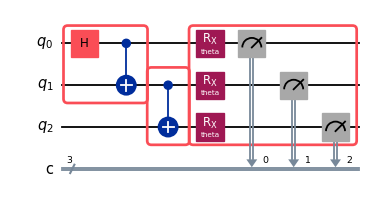

In [34]:
from samplomatic import InjectNoise

boxed_circuit = QuantumCircuit(3, 3)

with boxed_circuit.box(annotations=[Twirl(), InjectNoise(ref="r0", modifier_ref="m0")]):
    boxed_circuit.h(0)
    boxed_circuit.cx(0, 1)

with boxed_circuit.box(annotations=[Twirl(), InjectNoise(ref="r1", modifier_ref="m1")]):
    boxed_circuit.cx(1, 2)

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.rx(Parameter("theta"), [0, 1, 2])
    boxed_circuit.measure([0, 1, 2], [0, 1, 2])

template_circuit, samplex = build(boxed_circuit)

print(samplex)
boxed_circuit.draw("mpl", scale=0.65)

In [37]:
from qiskit.quantum_info import PauliLindbladMap

samplex_input = {
    "parameter_values": [0.1],
    "pauli_lindblad_maps.r0": PauliLindbladMap.from_list([("IX", 0.04), ("XX", 0.05)]),
    "pauli_lindblad_maps.r1": PauliLindbladMap.from_list([("XI", 0.02), ("IZ", 0.035)]),
    "noise_scales.m0": 1.2,
}

outputs = samplex.sample(samplex_input, num_randomizations=5)

print("Samplex outputs:")
print(outputs.describe())

Samplex outputs:
* 'measurement_flips.c' <bool['num_randomizations', 1, 3]>: Bit-flip corrections for measurement twirling.
* 'parameter_values' <float32['num_randomizations', 21]>: Parameter values valid for an associated template circuit.
* 'pauli_signs' <bool['num_randomizations', 2]>: Signs from sampled Pauli Lindblad maps, where boolean values represent the parity of the number of non-trivial factors in the sampled error that arise from negative rates. In other words, in order to implement basic PEC, the sign used to correct expectation values should be ``(-1)**bool_value``. The order matches the iteration order of boxes in the original circuit with noise injection annotations.



The boxing pass manager can automate `InjectNoise` annotation. `inject_noise_strategy` controls how noise models map to boxes:
- `"individual_modification"` — each gate box gets a unique `ref` and `modifier_ref`
- `"uniform_modification"` — all gate boxes share a single `modifier_ref` (uniform noise scaling)

In [38]:
boxing_pm_pec = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=True,
    inject_noise_targets="gates",
    inject_noise_strategy="individual_modification",
)

circuit = QuantumCircuit(3, 3)
circuit.h(0)
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.rx(Parameter("theta"), [0, 1, 2])
circuit.measure([0, 1, 2], [0, 1, 2])

boxed_auto = boxing_pm_pec.run(circuit)
template_auto, samplex_auto = build(boxed_auto)

print(samplex_auto)

Samplex(<25 nodes>)
  Inputs:
  - 'parameter_values' <float64[1]>: Input parameter values to use during sampling.
  - 'pauli_lindblad_maps.r209' <PauliLindbladMap>: A PauliLindblad map acting on 3 qubits,
      with 'num_terms_r209' terms.
  - 'pauli_lindblad_maps.r49a' <PauliLindbladMap>: A PauliLindblad map acting on 3 qubits,
      with 'num_terms_r49a' terms.

  - 'local_scales.m0' <float64['num_terms_r209']>: (Optional) An array of factors by which to
      scale individual rates of a Pauli Lindblad map, where the order should match the
      corresponding list of terms.
  - 'local_scales.m1' <float64['num_terms_r49a']>: (Optional) An array of factors by which to
      scale individual rates of a Pauli Lindblad map, where the order should match the
      corresponding list of terms.
  - 'noise_scales.m0' <float64[]>: (Optional) A scalar factor by which to scale rates of a
      Pauli Lindblad map.
  - 'noise_scales.m1' <float64[]>: (Optional) A scalar factor by which to scale rate

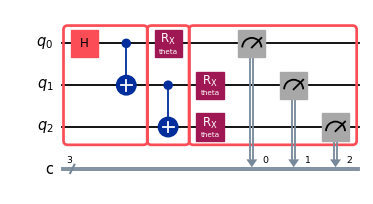

In [39]:
boxed_auto.draw("mpl", scale=0.65, fold=-1)

---

## The `ChangeBasis` Annotation

`ChangeBasis` adds basis-changing gates to a box, enabling measurement in the X or Y basis (not just Z). Two modes:
- `"prepare"` — at the beginning of a circuit, rotates Z eigenstates into X/Y eigenstates
- `"measure"` — before measurements, rotates X/Y back to Z for standard Z-basis measurement

The samplex input `basis_changes.<ref>` uses symplectic ordering: **I=0, Z=1, X=2, Y=3**. The virtual basis-changing gates travel with the Pauli-twirling dressing and get collected into the parametric template.

Samplex(<20 nodes>)
  Inputs:
  - 'basis_changes.conclude' <uint8[3]>: Basis changing gates, in the symplectic ordering
      I=0, Z=1, X=2, and Y=3.
  - 'parameter_values' <float64[1]>: Input parameter values to use during sampling.

  Outputs:
    * 'measurement_flips.c' <bool['num_randomizations', 1, 3]>: Bit-flip corrections for
        measurement twirling.
    * 'parameter_values' <float32['num_randomizations', 21]>: Parameter values valid for an
        associated template circuit.



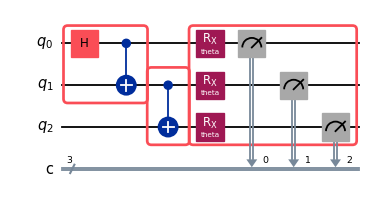

In [40]:
from samplomatic import ChangeBasis

boxed_circuit = QuantumCircuit(3, 3)

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.h(0)
    boxed_circuit.cx(0, 1)

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.cx(1, 2)

with boxed_circuit.box(annotations=[Twirl(), ChangeBasis(mode="measure", ref="conclude")]):
    boxed_circuit.rx(Parameter("theta"), [0, 1, 2])
    boxed_circuit.measure([0, 1, 2], [0, 1, 2])

template_circuit, samplex = build(boxed_circuit)

print(samplex)
boxed_circuit.draw("mpl", scale=0.65)

In [41]:
samplex_input = {
    "parameter_values": [0.1],
    "basis_changes.conclude": [0, 2, 3],  # I=0, Z=1, X=2, Y=3
}

outputs = samplex.sample(samplex_input, num_randomizations=5)

print("Samplex outputs:")
print(outputs.describe())
print(f"\nBasis changes [0, 2, 3] means: qubit 0 = I (Z-basis), qubit 1 = X-basis, qubit 2 = Y-basis")

Samplex outputs:
* 'measurement_flips.c' <bool['num_randomizations', 1, 3]>: Bit-flip corrections for measurement twirling.
* 'parameter_values' <float32['num_randomizations', 21]>: Parameter values valid for an associated template circuit.


Basis changes [0, 2, 3] means: qubit 0 = I (Z-basis), qubit 1 = X-basis, qubit 2 = Y-basis


In [42]:
boxing_pm_cb = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=True,
    measure_annotations="all",  # Twirl + ChangeBasis on measurement boxes
)

print("measure_annotations='all' adds both Twirl and ChangeBasis to measurement boxes automatically")

measure_annotations='all' adds both Twirl and ChangeBasis to measurement boxes automatically


---

## Full PEC Pipeline: NoiseLearnerV3 + Executor

This section implements the complete Probabilistic Error Cancellation pipeline from end to end:

1. **Prepare** — Create a mirror circuit (which should ideally return |0...0⟩), transpile and box it
2. **Learn** — Use `NoiseLearnerV3` to characterize noise on the boxed instructions
3. **Execute** — Submit both twirl-only and PEC-mitigated items via `Executor`
4. **Post-process** — Compare noisy (twirl) vs. PEC-corrected expectation values

We use a **mirror circuit** (`U · U†`) because the ideal output is known: all qubits should measure 0, giving ⟨Z⟩ = 1.0 for every qubit. Any deviation from 1.0 is pure noise.

### Step 1: Create a mirror circuit

A mirror circuit applies a parameterized unitary and then its inverse. Ideally it returns the input state unchanged. On noisy hardware, the output deviates — giving us a clear signal to measure how well PEC works.

Mirror circuit: 10 qubits, 20 parameters
Ideal output: all qubits measure 0 → ⟨Z⟩ = 1.0


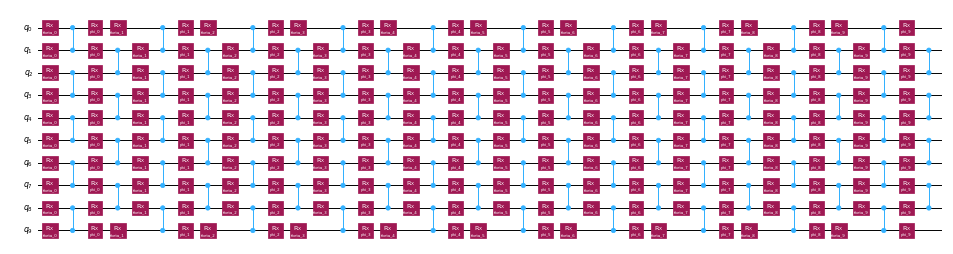

In [43]:
PEC_NUM_QUBITS = 10
PEC_NUM_LAYERS = 10

qubits = list(range(PEC_NUM_QUBITS))
forward_circuit = QuantumCircuit(PEC_NUM_QUBITS)

for layer_idx in range(PEC_NUM_LAYERS):
    forward_circuit.rx(Parameter(f"theta_{layer_idx}"), qubits)
    for i in range(PEC_NUM_QUBITS // 2):
        forward_circuit.cz(qubits[2 * i], qubits[2 * i + 1])

    forward_circuit.rx(Parameter(f"phi_{layer_idx}"), qubits)
    for i in range(PEC_NUM_QUBITS // 2 - 1):
        forward_circuit.cz(qubits[2 * i] + 1, qubits[2 * i + 1] + 1)

mirror_circuit = forward_circuit.compose(forward_circuit.inverse())
mirror_circuit.measure_all()

pec_parameter_values = np.random.rand(mirror_circuit.num_parameters)

print(f"Mirror circuit: {mirror_circuit.num_qubits} qubits, {mirror_circuit.num_parameters} parameters")
print(f"Ideal output: all qubits measure 0 → ⟨Z⟩ = 1.0")
forward_circuit.draw("mpl", scale=0.35, fold=100)

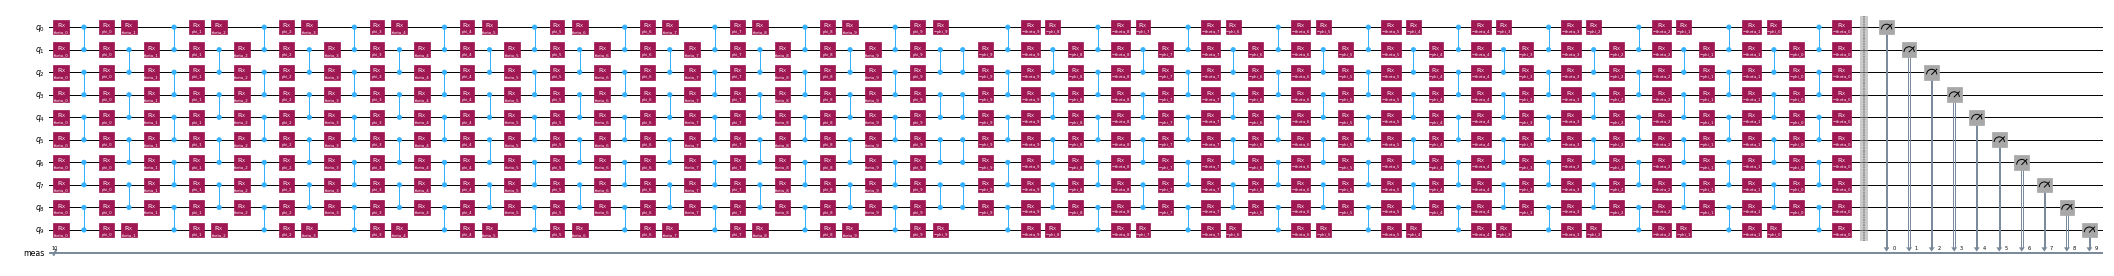

In [45]:
mirror_circuit.draw("mpl", scale=0.35, fold=100)

### Step 2: Transpile and box

We create **two** boxed versions of the mirror circuit:
- **Twirl-only** — `Twirl` annotations on all boxes (gate + measurement twirling, no noise injection)
- **PEC** — `Twirl` + `InjectNoise` on gate boxes (enables noise injection for PEC)

The boxing pass manager is appended as a `post_scheduling` stage so it runs after Qiskit's standard transpilation.

In [46]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm_twirl = generate_preset_pass_manager(backend=backend, optimization_level=0)
pm_twirl.post_scheduling = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=True,
)

pm_pec = generate_preset_pass_manager(backend=backend, optimization_level=0)
pm_pec.post_scheduling = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=True,
    inject_noise_targets="gates",
    inject_noise_strategy="uniform_modification",
)

mirror_circuit_twirl = pm_twirl.run(mirror_circuit)
mirror_circuit_pec = pm_pec.run(mirror_circuit)

print(f"Twirl circuit: {mirror_circuit_twirl.num_qubits} qubits, {len(mirror_circuit_twirl.data)} instructions")
print(f"PEC circuit:   {mirror_circuit_pec.num_qubits} qubits, {len(mirror_circuit_pec.data)} instructions")

Twirl circuit: 156 qubits, 41 instructions
PEC circuit:   156 qubits, 41 instructions


### Step 3: Learn noise with NoiseLearnerV3

`NoiseLearnerV3` characterizes the noise affecting each unique box instruction. We first identify **unique** instructions using `find_unique_box_instructions` — this minimizes the number of noise-learning experiments since identical gate types on the same qubits share a noise model.

The learner returns `PauliLindbladMap` objects describing the noise channel as:

$$\mathcal{E}(\rho) = \exp\left(\sum_j r_j \mathcal{D}_{P_j}\right)(\rho)$$

where $\mathcal{D}_{P_j}(\rho) = P_j \rho P_j - \rho$ are Pauli dissipators with rates $r_j$.

In [47]:
from samplomatic.utils import find_unique_box_instructions

unique_box_instructions = find_unique_box_instructions(mirror_circuit_pec.data)
print(f"Unique box instructions to learn: {len(unique_box_instructions)}")

Unique box instructions to learn: 3


In [48]:
from qiskit_ibm_runtime.noise_learner_v3 import NoiseLearnerV3

learner = NoiseLearnerV3(backend)

learner.options.shots_per_randomization = 128
learner.options.num_randomizations = 32
learner.options.layer_pair_depths = [0, 1, 2, 4, 16, 32]

learner_job = learner.run(unique_box_instructions)
print(f"Noise learner job: {learner_job.job_id()}")

Noise learner job: d6g4qm8ddp9c73cf4ksg


In [53]:
learner_result = learner_job.result()
noise_maps = learner_result.to_dict(instructions=unique_box_instructions, require_refs=False)

print(f"Learned noise maps for {len(noise_maps)} instruction refs:")
for ref, plm in noise_maps.items():
    print(f"  {ref}: {plm.num_qubits}-qubit")

Learned noise maps for 2 instruction refs:
  r27b: 10-qubit
  r241: 10-qubit


### Step 4: Build and execute via Executor

We create a single `QuantumProgram` with **two items**:
1. **Twirl-only** — gate + measurement twirling, no noise injection
2. **PEC** — twirling + noise injection at scale `-1.0` (the PEC inversion scale)

Both are submitted in one `Executor.run()` call.

In [56]:
PEC_NUM_RANDOMIZATIONS = 100
PEC_SHOTS = 1000

template_twirl, samplex_twirl = build(mirror_circuit_twirl)
template_pec, samplex_pec = build(mirror_circuit_pec)

pec_program = QuantumProgram(shots=PEC_SHOTS)

pec_program.append_samplex_item(
    template_twirl,
    samplex=samplex_twirl,
    samplex_arguments={"parameter_values": pec_parameter_values},
    shape=(PEC_NUM_RANDOMIZATIONS,),
)

pec_program.append_samplex_item(
    template_pec,
    samplex=samplex_pec,
    samplex_arguments={
        "parameter_values": pec_parameter_values,
        "pauli_lindblad_maps": noise_maps,
        "noise_scales": {ref: -1.0 for ref in noise_maps},
    },
    shape=(PEC_NUM_RANDOMIZATIONS,),
)

print(pec_program)

QuantumProgram(shots=1000, items=[
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x23d76a2e850>, <Samplex @ 0x23d76d01450>, samplex_arguments={'parameter_values'=<(20,), float64>}, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x23d75619250>, <Samplex @ 0x23d739b2490>, samplex_arguments={'pauli_lindblad_maps.r27b'=<PauliLindbladMap>, 'pauli_lindblad_maps.r241'=<PauliLindbladMap>, 'parameter_values'=<(20,), float64>, 'noise_scales.r27b'=<(), float64>, 'noise_scales.r241'=<(), float64>}, shape=(100,)),
])


In [57]:
pec_executor = Executor(backend)
pec_executor_job = pec_executor.run(pec_program)
print(f"Executor job: {pec_executor_job.job_id()}")

pec_executor_results = pec_executor_job.result()
print(f"Result items: {len(pec_executor_results)}")
print(f"Twirl result keys: {list(pec_executor_results[0].keys())}")
print(f"PEC result keys:   {list(pec_executor_results[1].keys())}")

Executor job: d6g52b8j9bds73cnpetg
Result items: 2
Twirl result keys: ['meas', 'measurement_flips.meas']
PEC result keys:   ['meas', 'measurement_flips.meas', 'pauli_signs']


### Step 5: Post-process and compare

**Twirl results**: undo measurement flips with XOR, then compute ⟨Z⟩ per qubit.

**PEC results**: additionally use `pauli_signs` for sign correction. The PEC estimator is:

$$\langle Z_i \rangle_{\text{PEC}} = 1 - \left\langle 2 \cdot \overline{m_i} \cdot s \right\rangle_{\text{randomizations}}$$

where $\overline{m_i}$ is the shot-averaged measurement for qubit $i$ and $s = \prod_j (-1)^{\text{pauli\_signs}_j}$ is the PEC sign.

In [58]:
twirl_result = pec_executor_results[0]
twirl_unflipped = twirl_result["meas"] ^ twirl_result["measurement_flips.meas"]
twirl_exp_vals = 1 - 2 * twirl_unflipped.mean(axis=1).mean(axis=0)

print("Twirl-only ⟨Z⟩ per qubit (ideal = 1.0):")
for qubit, val in enumerate(twirl_exp_vals):
    print(f"  Qubit {qubit} → {np.round(val, 3)}")

Twirl-only ⟨Z⟩ per qubit (ideal = 1.0):
  Qubit 0 → 0.638
  Qubit 1 → 0.63
  Qubit 2 → 0.524
  Qubit 3 → 0.465
  Qubit 4 → 0.474
  Qubit 5 → 0.502
  Qubit 6 → 0.546
  Qubit 7 → 0.565
  Qubit 8 → 0.576
  Qubit 9 → 0.623


In [59]:
pec_result = pec_executor_results[1]
pec_unflipped = pec_result["meas"] ^ pec_result["measurement_flips.meas"]

signs = np.prod((-1) ** pec_result["pauli_signs"], axis=-1)
signs = signs.reshape((signs.shape[0], 1))

pec_exp_vals = 1 - (2 * pec_unflipped.mean(axis=1) * signs).mean(axis=0)

print("PEC-corrected ⟨Z⟩ per qubit (ideal = 1.0):")
for qubit, val in enumerate(pec_exp_vals):
    print(f"  Qubit {qubit} → {np.round(val, 3)}")

PEC-corrected ⟨Z⟩ per qubit (ideal = 1.0):
  Qubit 0 → 0.961
  Qubit 1 → 0.954
  Qubit 2 → 0.903
  Qubit 3 → 0.886
  Qubit 4 → 0.88
  Qubit 5 → 0.867
  Qubit 6 → 0.862
  Qubit 7 → 0.864
  Qubit 8 → 0.868
  Qubit 9 → 0.877


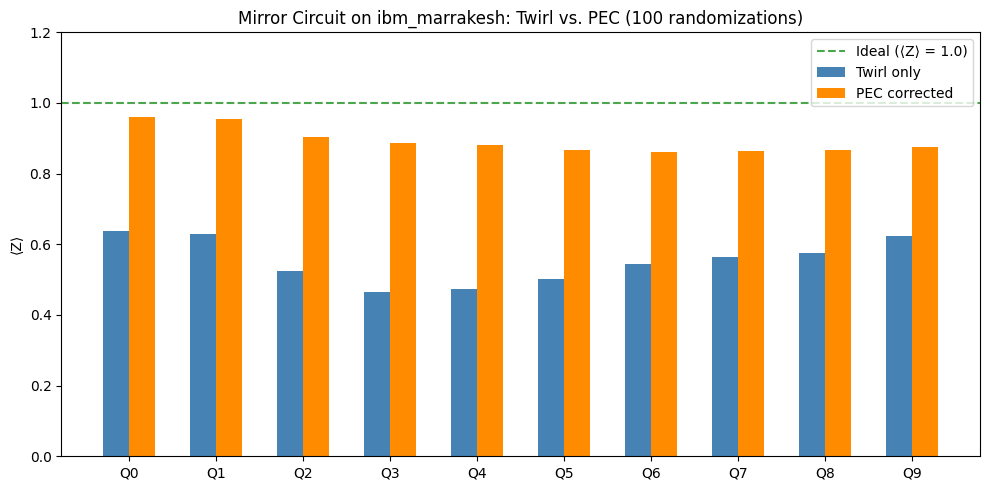

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(PEC_NUM_QUBITS)
w = 0.3

ax.bar(x - w/2, twirl_exp_vals, w, label="Twirl only", color="steelblue")
ax.bar(x + w/2, pec_exp_vals, w, label="PEC corrected", color="darkorange")
ax.axhline(y=1.0, color="green", linestyle="--", alpha=0.7, label="Ideal (⟨Z⟩ = 1.0)")

ax.set_xticks(x)
ax.set_xticklabels([f"Q{i}" for i in range(PEC_NUM_QUBITS)])
ax.set_ylabel("⟨Z⟩")
ax.set_title(f"Mirror Circuit on {backend.name}: Twirl vs. PEC ({PEC_NUM_RANDOMIZATIONS} randomizations)")
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

---

### Roadmap: Where Executor Fits

Executor is **not a replacement** for Sampler or Estimator — it is a lower-level primitive that sits *beneath* them:

```
           ┌──────────┐  ┌───────────┐
 User API  │ Estimator │  │  Sampler  │   ← High-level (Phase 1–2)
           └─────┬─────┘  └─────┬─────┘
                 │               │
           ┌─────▼───────────────▼─────┐
 Low-level │        Executor           │   ← Low-level (Phase 3)
           │  (template + samplex)     │
           └───────────┬───────────────┘
                       │
           ┌───────────▼───────────────┐
 Hardware  │    Qiskit Runtime / QPU   │
           └───────────────────────────┘
```

**What's coming:**
- Estimator and Sampler abstractions **will not go away** — they can be reimplemented with Executor as a backend
- Open-source error mitigation recipes built on the (template, samplex) → Executor pattern
- "samplex" as optional semantics attached to `QuantumProgram` items
- Semantics for computing expectation values directly from Executor results

---

## Conclusion

| Aspect | Sampler (Phase 1–2) | Samplomatic + SamplerV2 | Samplomatic + Executor | Full PEC Pipeline |
|--------|---------------------|------------------------|------------------------|-------------------|
| **Error mitigation** | Server-side, resilience levels | Client-side, composed from modules | Client-side compose, server-side execute | PEC via NoiseLearnerV3 + InjectNoise |
| **Twirling** | Automatic, opaque | Explicit, inspectable | Explicit, inspectable | Explicit + noise injection |
| **Circuit submission** | 1 circuit per call | N circuits (1 per randomization) | 1 template + samplex per item | Same as Executor |
| **Noise learning** | Built-in (hidden) | Not included | Not included | NoiseLearnerV3 → PauliLindbladMaps |
| **Result format** | Count dictionaries | Count dictionaries | Numpy boolean arrays | Numpy + pauli_signs |
| **Scaling** | N/A | Impractical at 10⁶ | Single job, shape=(10⁶,) | Single job + noise maps |
| **Use case** | Standard workflows | Research, custom protocols | Large-scale twirling | Production error cancellation |

### Key Annotations Summary

| Annotation | Purpose | Samplex Inputs Added | Samplex Outputs Added |
|-----------|---------|---------------------|----------------------|
| `Twirl()` | Pauli twirling | — | `measurement_flips.c`, `parameter_values` |
| `InjectNoise(ref, modifier_ref)` | PEC noise injection | `pauli_lindblad_maps.<ref>`, `noise_scales.<modifier_ref>` | `pauli_signs` |
| `ChangeBasis(mode, ref)` | X/Y basis measurement | `basis_changes.<ref>` | — |

**Bottom line**: The three approaches form a spectrum of control vs. convenience. Sampler is the simplest. Samplomatic + SamplerV2 gives full client-side control. Samplomatic + Executor scales to production. The full PEC pipeline (NoiseLearnerV3 + InjectNoise + Executor) delivers the highest accuracy by actively cancelling noise.

## References

- [Samplomatic GitHub](https://github.com/Qiskit/samplomatic)
- [Samplomatic Documentation](https://qiskit.github.io/samplomatic)
- [Samplomatic Hello World Tutorial (QDC 2025)](https://github.com/qiskit-community/qdc-challenges-2025/blob/main/day3_tutorials/Track_A/hello_samplomatic/Samplomatic%20-%20Hello%20World.ipynb)
- [Qiskit Advocate Seminar: Phase 3 Primitives (Jan 2026)](https://www.crowdcast.io/c/jan-2026-dynamic-circuits)
- [IBM Quantum Primitives Documentation](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime)